# Frozen Quality-Matched Nuclear-IOD Genome-Size Analysis

            This notebook analyzes every nucleus in the final reviewed panel:
            721 manually accepted nuclei from 20 species. The primary estimator
            is the mean of the image-specific median IOD values, giving every
            observed image/specimen equal weight.

            **Interpretation boundary:** this is a relative nuclear-IOD
            genome-size proxy. It is not an absolute genome-size estimate,
            C-value, or picogram measurement because no independent
            DNA-content standard was imaged and calibrated with these samples.


## Exact frozen inputs and analysis setup


In [1]:
from pathlib import Path
import sys
import json
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from IPython.display import display, HTML, Image


def find_project_root(start=None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "paths.yaml").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root")


PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "path_analysis" / "scripts"))
import build_frozen_genome_iod_notebook as analysis

FROZEN_PATH = analysis.FROZEN_PATH
MATCH_MANIFEST_PATH = analysis.MATCH_MANIFEST_PATH
REPORT_DIR = analysis.REPORT_DIR
FIGURE_DIR = analysis.FIGURE_DIR
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

frozen = pd.read_csv(FROZEN_PATH, low_memory=False)
match_manifest = json.loads(MATCH_MANIFEST_PATH.read_text())
species_summary, image_summary = analysis.summarize_species(
    frozen, n_bootstrap=2000, seed=20260710
)
quality_balance, quality_residual = analysis.frozen_quality_diagnostics(frozen)
anchor = float(species_summary["relative_iod_anchor"].iloc[0])

plt.rcParams.update({
    "figure.dpi": 115,
    "savefig.dpi": 190,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 800)
pd.set_option("display.width", 180)


def short_species(value):
    return str(value).replace("D. ", "")


def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    return path


print("Frozen source:", FROZEN_PATH)
print("Frozen SHA-256:", analysis.sha256_file(FROZEN_PATH))
print("Rows:", len(frozen), "| Species:", frozen["species"].nunique())
print("Relative-index anchor IOD:", round(anchor, 3))


Frozen source: /home/jake/Projects/Desmognathus_TE/path_analysis/data/external/derived/image_quality_matched_genome_iod/image_quality_matched_nuclei_frozen_reviewed.csv.gz
Frozen SHA-256: f22d014f9f395c5aadec8fe2538f6f651d1328884ef618e0baf0a97a1e00dcbe
Rows: 721 | Species: 20
Relative-index anchor IOD: 966.0


## Freeze and source audit

            These checks are hard failures: all rows must be reviewed keeps,
            no rejected key can appear, every species must retain at least 30
            nuclei, and the source manifest must mark the panel frozen.


In [2]:
decisions = analysis.load_latest_decisions()
problem_keys = set(map(
    tuple,
    decisions.loc[decisions["decision"].eq("problem"), ["species", "review_key"]]
    .itertuples(index=False, name=None),
))
frozen_keys = set(map(
    tuple,
    frozen[["species", "review_key"]].itertuples(index=False, name=None),
))
counts = frozen.groupby("species").size()
audit = pd.DataFrame({
    "check": [
        "manifest freeze status",
        "reviewed nuclei",
        "primary species",
        "images/specimens",
        "minimum nuclei per species",
        "maximum nuclei per species",
        "duplicate keys",
        "rejected-key leaks",
        "all rows explicitly reviewed keep",
    ],
    "value": [
        match_manifest["freeze_status"],
        len(frozen),
        frozen["species"].nunique(),
        f'{frozen["filename"].nunique()} / {frozen["specimen_group"].nunique()}',
        int(counts.min()),
        int(counts.max()),
        int(frozen.duplicated(["species", "review_key"]).sum()),
        len(frozen_keys & problem_keys),
        bool(frozen["review_status"].eq("reviewed_keep").all()),
    ],
})
display(audit)
assert match_manifest["freeze_status"] == "frozen_reviewed_only_no_further_replacement"
assert frozen.duplicated(["species", "review_key"]).sum() == 0
assert not (frozen_keys & problem_keys)
assert frozen["review_status"].eq("reviewed_keep").all()
assert counts.min() >= 30


,check,value
0,manifest freeze status,frozen_reviewed_only_no_further_replacement
1,reviewed nuclei,721
2,primary species,20
3,images/specimens,41 / 41
4,minimum nuclei per species,33
5,maximum nuclei per species,39
6,duplicate keys,0
7,rejected-key leaks,0
8,all rows explicitly reviewed keep,True


## Complete species-level results


In [3]:
summary_columns = [
    "relative_iod_rank",
    "species",
    "n_nuclei",
    "n_images",
    "n_specimens",
    "iod_equal_image_estimate",
    "iod_equal_image_ci_low",
    "iod_equal_image_ci_high",
    "relative_iod_index",
    "relative_iod_ci_low",
    "relative_iod_ci_high",
    "iod_pooled_nucleus_median",
    "iod_trimmed_mean_10pct",
    "pooled_median_difference_pct",
    "trimmed_mean_difference_pct",
    "median_nucleus_area_um2",
    "median_nucleus_mean_od",
    "image_median_iod_min",
    "image_median_iod_max",
    "estimate_support",
]
display(
    species_summary[summary_columns]
    .style.format({
        "iod_equal_image_estimate": "{:.2f}",
        "iod_equal_image_ci_low": "{:.2f}",
        "iod_equal_image_ci_high": "{:.2f}",
        "relative_iod_index": "{:.3f}",
        "relative_iod_ci_low": "{:.3f}",
        "relative_iod_ci_high": "{:.3f}",
        "iod_pooled_nucleus_median": "{:.2f}",
        "iod_trimmed_mean_10pct": "{:.2f}",
        "pooled_median_difference_pct": "{:+.1f}%",
        "trimmed_mean_difference_pct": "{:+.1f}%",
        "median_nucleus_area_um2": "{:.2f}",
        "median_nucleus_mean_od": "{:.4f}",
        "image_median_iod_min": "{:.2f}",
        "image_median_iod_max": "{:.2f}",
    })
)


,relative_iod_rank,species,n_nuclei,n_images,n_specimens,iod_equal_image_estimate,iod_equal_image_ci_low,iod_equal_image_ci_high,relative_iod_index,relative_iod_ci_low,relative_iod_ci_high,iod_pooled_nucleus_median,iod_trimmed_mean_10pct,pooled_median_difference_pct,trimmed_mean_difference_pct,median_nucleus_area_um2,median_nucleus_mean_od,image_median_iod_min,image_median_iod_max,estimate_support
0,1,D. valtos,37,2,2,1301.70,1250.49,1343.68,1.348,1.295,1.391,1307.05,1295.78,+0.4%,-0.5%,50.00,0.3716,1277.70,1325.71,multiple_observed_images
1,2,D. bairdi,37,1,1,1077.42,1054.69,1110.33,1.115,1.092,1.149,1077.42,1078.77,+0.0%,+0.1%,46.35,0.3410,1077.42,1077.42,single_observed_image
2,3,D. intermedius,35,2,2,1038.66,979.10,1098.87,1.075,1.014,1.138,1044.93,1036.19,+0.6%,-0.2%,44.47,0.3358,1004.00,1073.32,multiple_observed_images
3,4,D. marmoratus,37,2,2,1031.01,984.25,1081.86,1.067,1.019,1.120,1024.51,1023.24,-0.6%,-0.8%,46.27,0.3201,993.78,1068.24,multiple_observed_images
4,5,D. auriculatus,36,2,2,1017.98,917.86,1121.40,1.054,0.950,1.161,961.87,952.58,-5.5%,-6.4%,48.06,0.2858,938.50,1097.45,multiple_observed_images
5,6,D. amphileucus,33,2,2,1001.33,913.48,1064.66,1.037,0.946,1.102,992.60,987.26,-0.9%,-1.4%,42.22,0.3325,958.91,1043.76,multiple_observed_images
6,7,D. kanawha,34,2,2,984.69,882.06,1238.01,1.019,0.913,1.282,899.81,907.44,-8.6%,-7.8%,41.28,0.3141,891.20,1078.18,multiple_observed_images
7,8,D. brimleyorum,35,2,2,981.91,906.01,1074.43,1.016,0.938,1.112,1022.67,1022.14,+4.2%,+4.1%,44.18,0.3311,922.51,1041.30,multiple_observed_images
8,9,D. folkertsi,37,2,2,977.04,939.84,1013.04,1.011,0.973,1.049,978.20,981.99,+0.1%,+0.5%,46.24,0.3078,964.22,989.86,multiple_observed_images
9,10,D. monticola,36,2,2,969.17,902.26,1092.54,1.003,0.934,1.131,957.36,972.58,-1.2%,+0.4%,41.21,0.3319,949.57,988.77,multiple_observed_images


## All 721 raw nuclei

            Every accepted nucleus is included below. IOD, its two algebraic
            components, image identity, and the two matching-quality features
            are visible. The frozen source download retains all 189 provenance
            and QC columns.


In [4]:
raw_columns = [
    "species",
    "filename",
    "specimen_group",
    "nucleus_label",
    "review_key",
    "nuc_iod",
    "nuc_area_um2",
    "nuc_mean_od",
    "match_log_edge_sharpness",
    "match_log_relative_ring_noise",
    "quality_match_distance",
    "review_status",
]
raw_display = frozen[raw_columns].sort_values(
    ["species", "filename", "nuc_iod"], kind="mergesort"
)
relative_source_link = (
    "../../../path_analysis/data/external/derived/image_quality_matched_genome_iod/"
    "image_quality_matched_nuclei_frozen_reviewed.csv.gz"
)
display(HTML(
    f'<p><a href="{relative_source_link}">Download the complete frozen 189-column CSV</a></p>'
    '<div style="max-height:620px;overflow:auto;border:1px solid #ccd3da;padding:4px">'
    + raw_display.to_html(index=False, float_format=lambda value: f"{value:.5f}")
    + "</div>"
))
print("Displayed raw nuclei:", len(raw_display))


species,filename,specimen_group,nucleus_label,review_key,nuc_iod,nuc_area_um2,nuc_mean_od,match_log_edge_sharpness,match_log_relative_ring_noise,quality_match_distance,review_status
D. amphileucus,Process_337_raw_green.ome.tiff,3442,32,Process_337_raw_green.ome.tiff::tile_y032768_x040960.tiff::32,791.53337,41.77440,0.27285,0.10981,0.11061,0.09715,reviewed_keep
D. amphileucus,Process_337_raw_green.ome.tiff,3442,86,Process_337_raw_green.ome.tiff::tile_y020480_x094208.tiff::86,792.62419,34.11360,0.33458,0.11659,0.08572,0.02129,reviewed_keep
D. amphileucus,Process_337_raw_green.ome.tiff,3442,37,Process_337_raw_green.ome.tiff::tile_y045056_x049152.tiff::37,806.12161,36.59040,0.31725,0.11396,0.12063,0.04688,reviewed_keep
D. amphileucus,Process_337_raw_green.ome.tiff,3442,86,Process_337_raw_green.ome.tiff::tile_y045056_x049152.tiff::86,876.56727,41.52960,0.30394,0.11365,0.11912,0.08104,reviewed_keep
D. amphileucus,Process_337_raw_green.ome.tiff,3442,62,Process_337_raw_green.ome.tiff::tile_y020480_x094208.tiff::62,884.15860,40.14720,0.31713,0.11659,0.12619,0.04663,reviewed_keep
D. amphileucus,Process_337_raw_green.ome.tiff,3442,100,Process_337_raw_green.ome.tiff::tile_y045056_x049152.tiff::100,900.40166,38.99520,0.33250,0.12392,0.13431,0.01982,reviewed_keep
D. amphileucus,Process_337_raw_green.ome.tiff,3442,95,Process_337_raw_green.ome.tiff::tile_y040960_x094208.tiff::95,913.08160,40.62240,0.32367,0.11489,0.12629,0.00131,reviewed_keep
D. amphileucus,Process_337_raw_green.ome.tiff,3442,91,Process_337_raw_green.ome.tiff::tile_y032768_x040960.tiff::91,934.01505,41.78880,0.32185,0.10939,0.08752,0.05812,reviewed_keep
D. amphileucus,Process_337_raw_green.ome.tiff,3442,23,Process_337_raw_green.ome.tiff::tile_y040960_x094208.tiff::23,983.80515,41.90400,0.33808,0.10932,0.10236,0.03768,reviewed_keep
D. amphileucus,Process_337_raw_green.ome.tiff,3442,75,Process_337_raw_green.ome.tiff::tile_y040960_x094208.tiff::75,992.66124,45.36000,0.31513,0.11170,0.07869,0.01628,reviewed_keep


Displayed raw nuclei: 721


## Raw nucleus-level IOD distributions


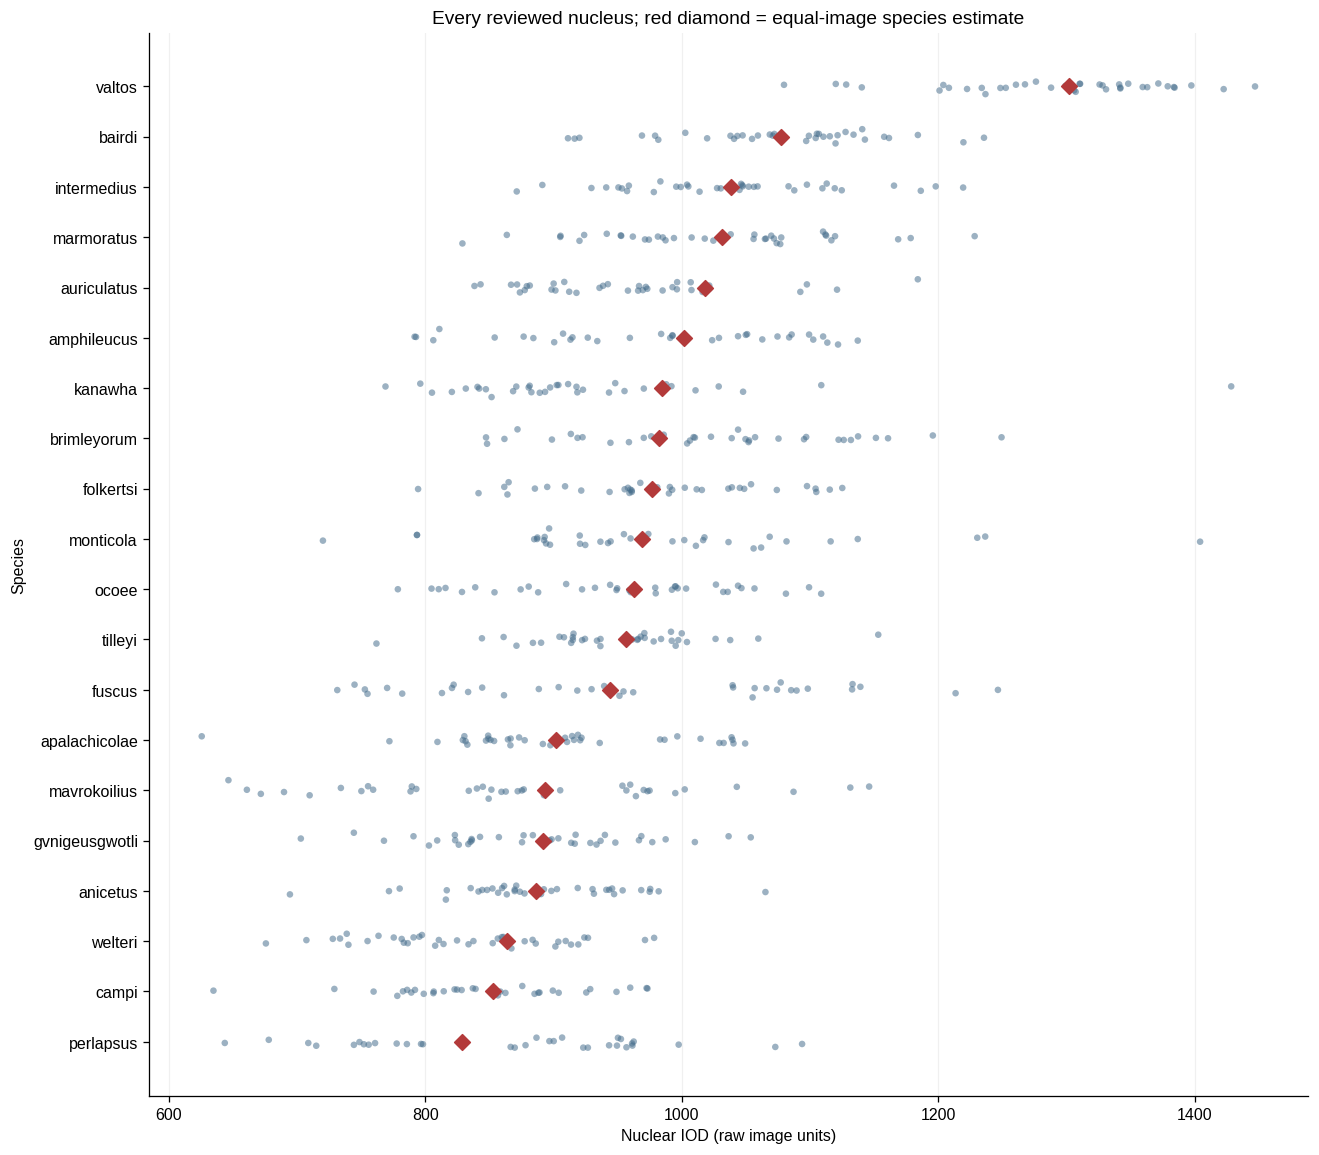

In [5]:
order = species_summary.sort_values("iod_equal_image_estimate")["species"].tolist()
rng = np.random.default_rng(20260710)
fig, ax = plt.subplots(figsize=(13, 12))
for y, species in enumerate(order):
    values = frozen.loc[frozen["species"].eq(species), "nuc_iod"].to_numpy()
    jitter = rng.normal(0, 0.065, size=len(values))
    ax.scatter(values, y + jitter, s=17, alpha=0.52, color="#426B8A", edgecolor="none")
    estimate = species_summary.loc[
        species_summary["species"].eq(species), "iod_equal_image_estimate"
    ].iloc[0]
    ax.scatter(estimate, y, marker="D", s=48, color="#B33A3A", zorder=5)
ax.set_yticks(range(len(order)), [short_species(value) for value in order])
ax.set_xlabel("Nuclear IOD (raw image units)")
ax.set_ylabel("Species")
ax.set_title("Every reviewed nucleus; red diamond = equal-image species estimate")
ax.grid(axis="x", alpha=0.18)
save_figure(fig, "01_all_raw_nuclear_iod.png")
plt.show()


## Primary relative IOD estimates and conditional uncertainty

            The species index is normalized so the median species estimate is
            1.0. Confidence intervals use hierarchical resampling of images and
            then nuclei within images. They are conditional on the images and
            specimens observed here; the three single-image species cannot
            express between-image uncertainty. The index intervals divide the
            raw-IOD intervals by the observed anchor and therefore treat that
            anchor as fixed.


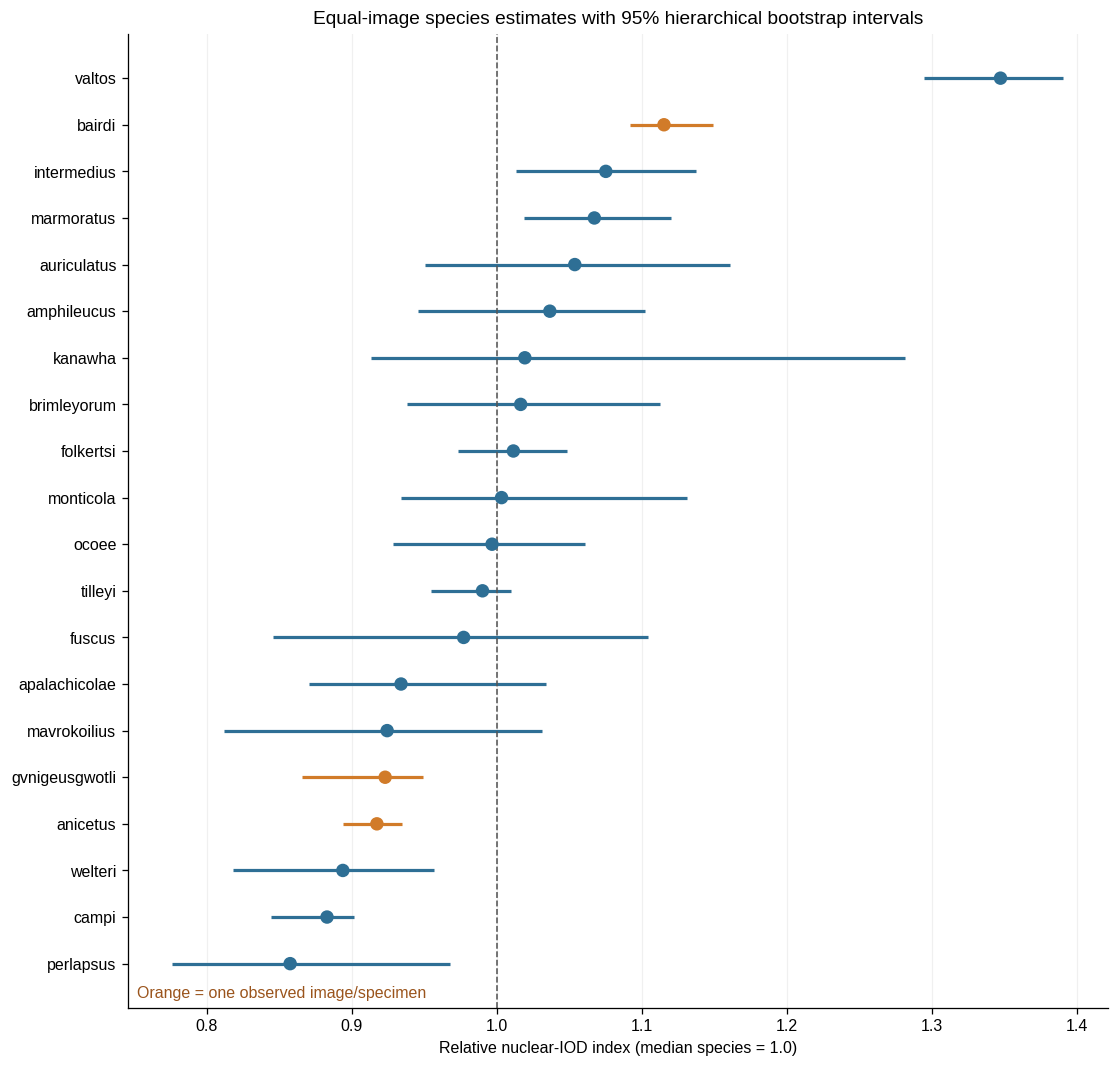

In [6]:
plot_data = species_summary.sort_values("relative_iod_index")
y = np.arange(len(plot_data))
x = plot_data["relative_iod_index"].to_numpy()
low = plot_data["relative_iod_ci_low"].to_numpy()
high = plot_data["relative_iod_ci_high"].to_numpy()
colors = np.where(plot_data["n_images"].eq(1), "#D17B29", "#2E6F95")
fig, ax = plt.subplots(figsize=(11, 11))
ax.hlines(y, low, high, color=colors, linewidth=2)
ax.scatter(x, y, color=colors, s=55, zorder=3)
ax.axvline(1.0, color="#555555", linestyle="--", linewidth=1)
ax.set_yticks(y, [short_species(value) for value in plot_data["species"]])
ax.set_xlabel("Relative nuclear-IOD index (median species = 1.0)")
ax.set_title("Equal-image species estimates with 95% hierarchical bootstrap intervals")
ax.grid(axis="x", alpha=0.18)
ax.text(
    0.01,
    0.01,
    "Orange = one observed image/specimen",
    transform=ax.transAxes,
    color="#9A541C",
)
save_figure(fig, "02_relative_iod_estimates.png")
plt.show()


## Measured-only time-calibrated phylogeny

            This panel aligns the exact 20-species overlap across the frozen
            genome-IOD and literal-largest size panels. Every violin is a
            bootstrap distribution of the plotted estimator. Genome is shown
            as relative nuclear IOD, never picograms; nucleus and cell areas
            are medians of the 50 manually vetted largest cells and their
            corresponding nuclei. No species is filled by phylogenetic
            imputation.


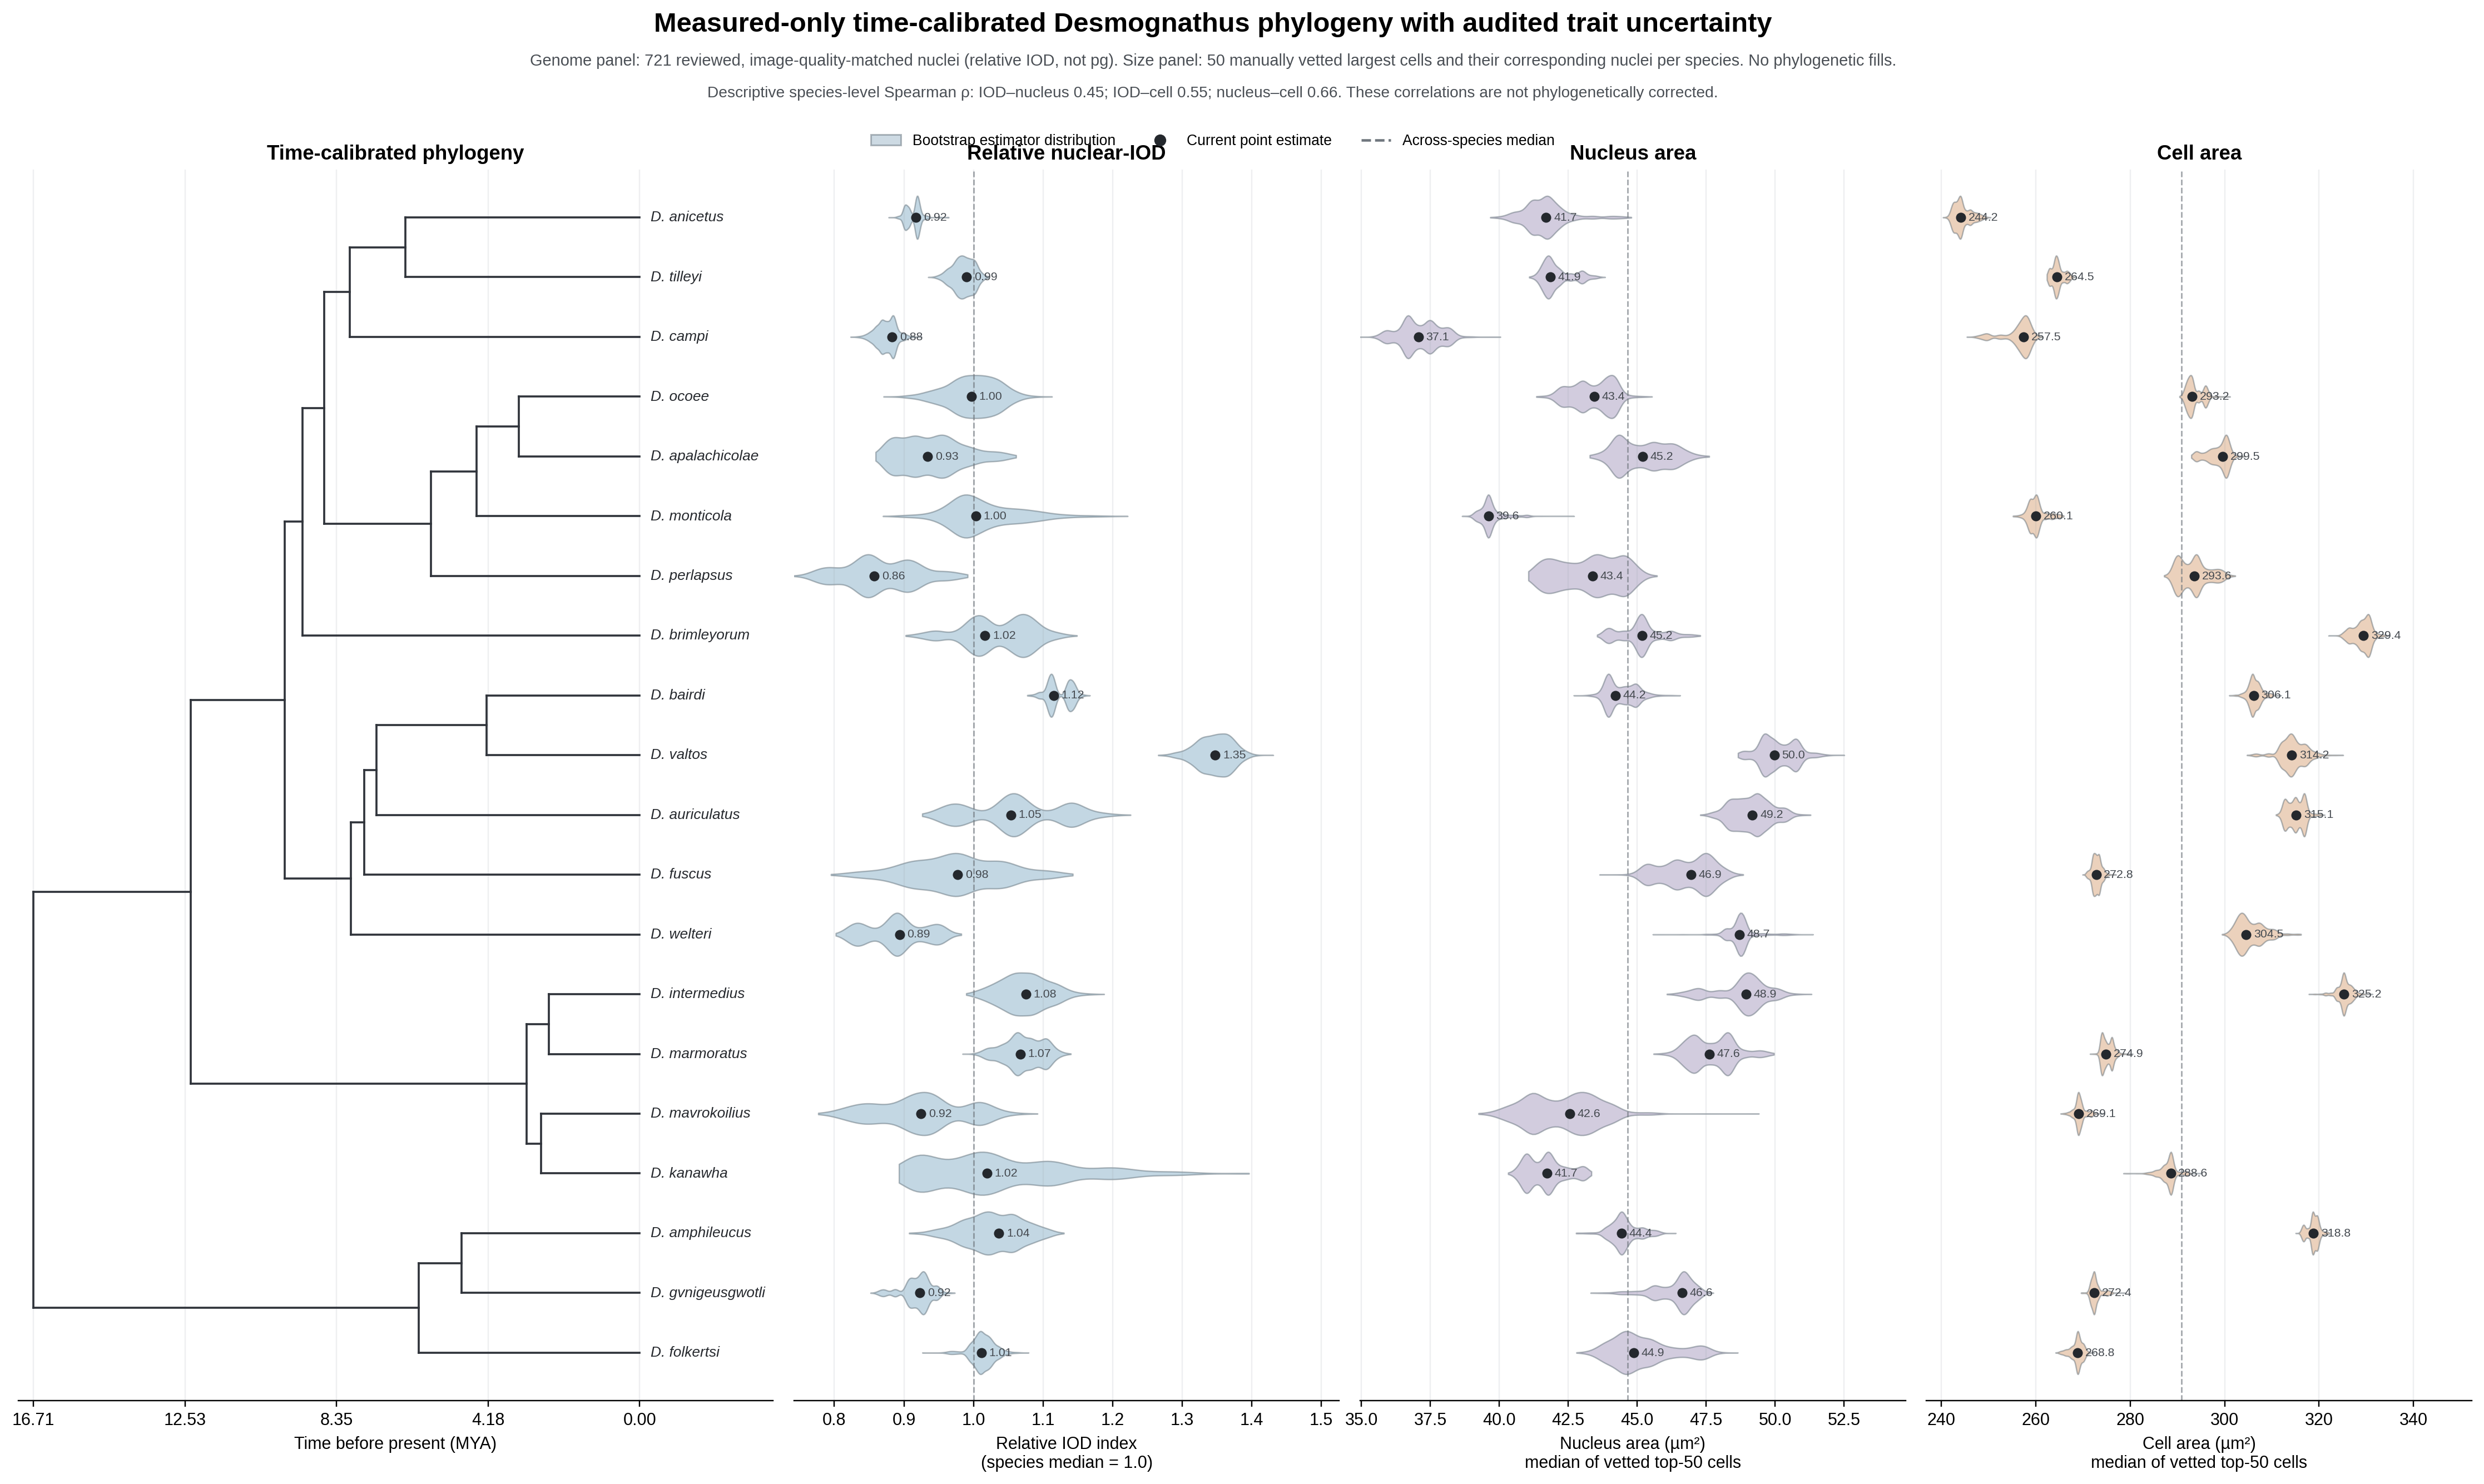

,species,n_genome_nuclei,n_genome_images,n_size_cells,n_size_images,relative_iod_index,relative_iod_index_ci_low,relative_iod_index_ci_high,nucleus_area_um2,nucleus_area_um2_ci_low,nucleus_area_um2_ci_high,cell_area_um2,cell_area_um2_ci_low,cell_area_um2_ci_high,tree_display_order
0,D. anicetus,39,1,50,1,0.917263,0.893827,0.934323,41.6952,40.43304,44.04960,244.1952,242.17200,248.50080,1
1,D. tilleyi,36,2,50,2,0.990127,0.954464,1.010944,41.8536,41.39280,43.30800,264.4776,262.69920,267.23520,2
2,D. campi,36,2,50,2,0.882856,0.845916,0.901293,37.0728,35.83440,38.26080,257.4504,248.55840,259.34400,3
3,D. ocoee,35,3,50,2,0.996717,0.925929,1.062423,43.4448,42.06960,44.51076,293.1552,291.44880,296.75520,4
4,D. apalachicolae,37,2,50,1,0.933918,0.870494,1.038278,45.2016,43.71840,46.85940,299.5488,293.76486,301.44240,5
5,D. monticola,36,2,50,2,1.003283,0.929084,1.133947,39.6072,39.12480,40.96800,260.0784,257.16960,264.94560,6
6,D. perlapsus,33,3,50,1,0.857423,0.774193,0.970469,43.3800,41.32800,45.00000,293.5512,289.18800,299.82240,7
7,D. brimleyorum,35,2,50,2,1.016466,0.937894,1.114893,45.1656,43.89120,46.84320,329.4000,325.26720,332.56080,8
8,D. bairdi,37,1,50,1,1.115342,1.091810,1.149415,44.2080,43.66080,45.43200,306.1368,303.52320,309.71520,9
9,D. valtos,37,2,50,2,1.347519,1.292771,1.389766,49.9680,48.81600,51.43734,314.1936,308.98080,319.67280,10


,comparison,left_metric,right_metric,spearman_rho,p_value_descriptive_only,n_species,phylogenetically_corrected
0,relative_iod_vs_nucleus_area,relative_iod_index,nucleus_area_um2,0.445113,0.049225,20,False
1,relative_iod_vs_cell_area,relative_iod_index,cell_area_um2,0.547368,0.012490,20,False
2,nucleus_area_vs_cell_area,nucleus_area_um2,cell_area_um2,0.658647,0.001589,20,False


In [7]:
phylogeny_figure = FIGURE_DIR / "07_measured_phylogeny_genome_nucleus_cell.png"
phylogeny_summary_path = REPORT_DIR / "phylogeny_genome_nucleus_cell_summary.csv"
phylogeny_correlation_path = REPORT_DIR / "phylogeny_genome_nucleus_cell_correlations.csv"
assert phylogeny_figure.exists(), "Run the measured phylogeny figure builder first"
assert phylogeny_summary_path.exists()
assert phylogeny_correlation_path.exists()
display(Image(filename=str(phylogeny_figure)))
display(pd.read_csv(phylogeny_summary_path))
display(pd.read_csv(phylogeny_correlation_path))


## Image-to-image variation within species


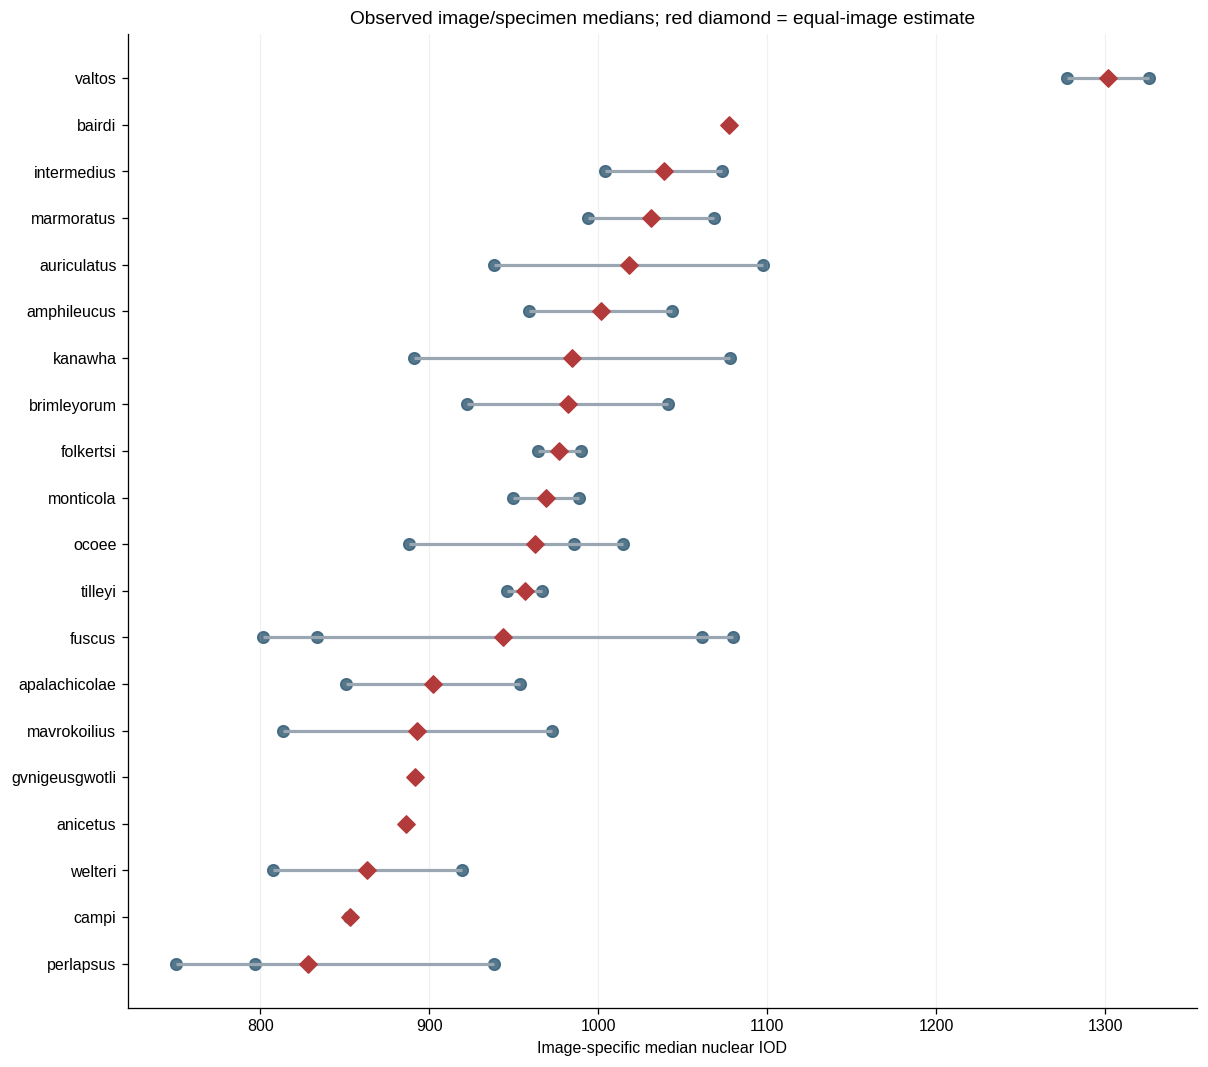

,species,filename,specimen_group,n_nuclei,image_median_iod,image_mean_iod,image_median_nucleus_area_um2,image_median_mean_od,image_median_match_log_edge_sharpness,image_median_match_log_relative_ring_noise
0,D. amphileucus,Process_337_raw_green.ome.tiff,3442,16,958.910100,954.290142,41.8464,0.325934,0.110751,0.104804
1,D. amphileucus,Process_338_raw_green.ome.tiff,3437,17,1043.757034,1008.816285,42.3504,0.343207,0.109622,0.106543
2,D. anicetus,Process_343_raw_green.ome.tiff,3441,39,886.076743,887.791193,40.1904,0.316773,0.109817,0.106610
3,D. apalachicolae,Process_356_raw_green.ome.tiff,3471,18,953.559841,957.068988,44.7840,0.310104,0.108604,0.100363
4,D. apalachicolae,Process_357_raw_green.ome.tiff,3472,19,850.770405,855.021525,38.2320,0.321398,0.112857,0.121027
5,D. auriculatus,Process_324_raw_green.ome.tiff,3462,5,1097.454415,1092.110361,45.9216,0.329243,0.107846,0.100379
6,D. auriculatus,Process_331_raw_green.ome.tiff,3463,31,938.497898,937.652216,48.1536,0.283869,0.109539,0.105361
7,D. bairdi,Process_359_raw_green.ome.tiff,3455,37,1077.420946,1076.447484,46.3536,0.341027,0.109854,0.102191
8,D. brimleyorum,Process_348_raw_green.ome.tiff,3464,22,1041.303297,1054.521779,45.4248,0.331329,0.110265,0.105905
9,D. brimleyorum,Process_349_raw_green.ome.tiff,3468,13,922.510534,969.619666,43.2576,0.331115,0.108393,0.104850


In [8]:
species_order = species_summary.sort_values("iod_equal_image_estimate")["species"].tolist()
fig, ax = plt.subplots(figsize=(12, 11))
for y, species in enumerate(species_order):
    image_values = image_summary.loc[
        image_summary["species"].eq(species), "image_median_iod"
    ].to_numpy()
    estimate = species_summary.loc[
        species_summary["species"].eq(species), "iod_equal_image_estimate"
    ].iloc[0]
    if len(image_values) > 1:
        ax.hlines(y, image_values.min(), image_values.max(), color="#9AA6B2", linewidth=2)
    ax.scatter(image_values, np.full(len(image_values), y), s=52, color="#365F78", alpha=0.85)
    ax.scatter(estimate, y, s=58, marker="D", color="#B33A3A", zorder=4)
ax.set_yticks(range(len(species_order)), [short_species(value) for value in species_order])
ax.set_xlabel("Image-specific median nuclear IOD")
ax.set_title("Observed image/specimen medians; red diamond = equal-image estimate")
ax.grid(axis="x", alpha=0.18)
save_figure(fig, "03_image_level_iod.png")
plt.show()
display(image_summary.sort_values(["species", "filename"]))


## What makes up IOD?

            Nuclear IOD is algebraically the nuclear mask area in pixels
            multiplied by mean optical density. Its association with nuclear
            area therefore cannot independently validate a biological
            genome-size mechanism. Both components are shown explicitly.


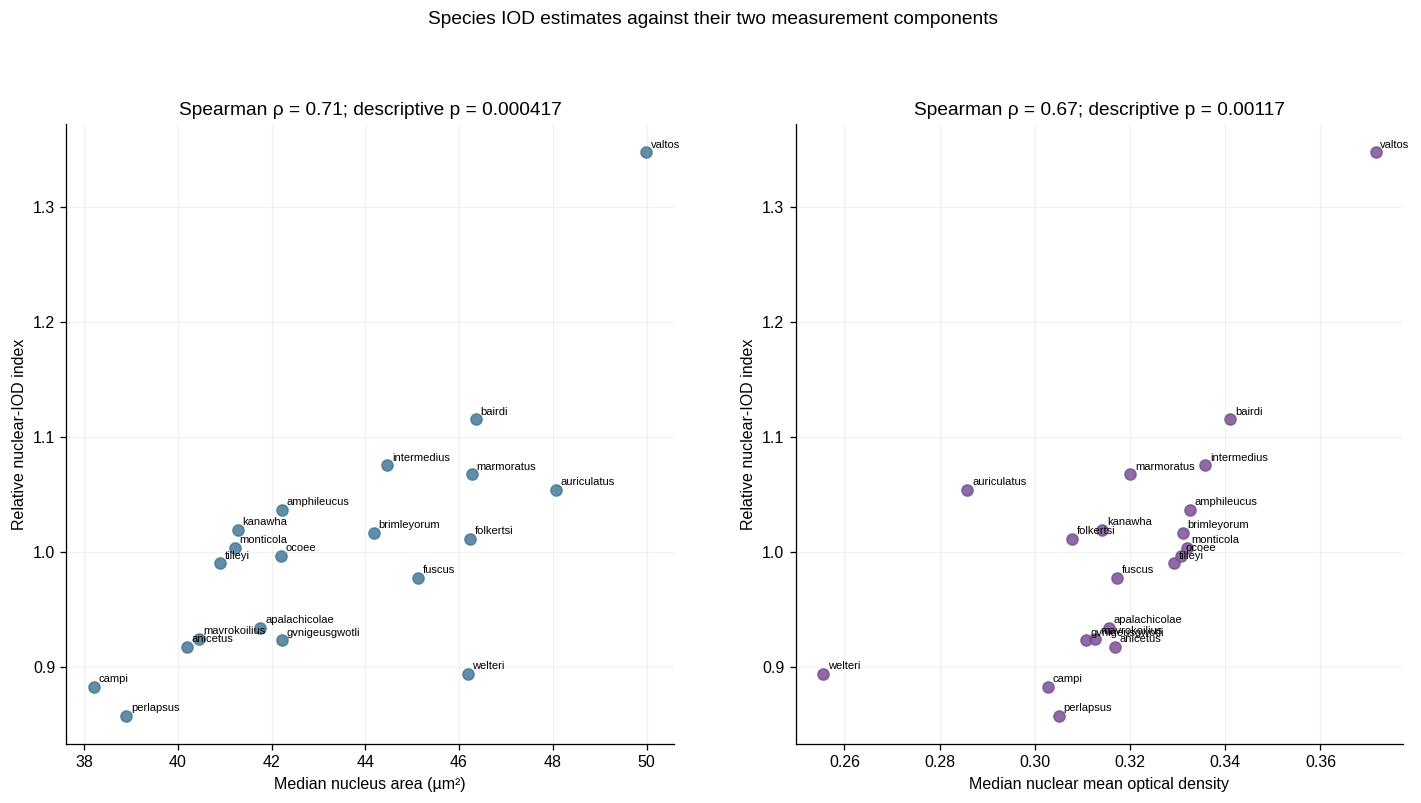

IOD vs median nucleus area: rho=0.713, p=0.0004171
IOD vs median mean OD: rho=0.672, p=0.001168


In [9]:
component_data = species_summary.copy()
rho_area, p_area = spearmanr(
    component_data["median_nucleus_area_um2"],
    component_data["iod_equal_image_estimate"],
)
rho_od, p_od = spearmanr(
    component_data["median_nucleus_mean_od"],
    component_data["iod_equal_image_estimate"],
)
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
specs = [
    (
        "median_nucleus_area_um2",
        "Median nucleus area (µm²)",
        rho_area,
        p_area,
        "#477998",
    ),
    (
        "median_nucleus_mean_od",
        "Median nuclear mean optical density",
        rho_od,
        p_od,
        "#7A5195",
    ),
]
for ax, (column, xlabel, rho, p_value, color) in zip(axes, specs):
    ax.scatter(
        component_data[column],
        component_data["relative_iod_index"],
        s=48,
        color=color,
        alpha=0.85,
    )
    for row in component_data.itertuples():
        ax.annotate(
            short_species(row.species),
            (getattr(row, column), row.relative_iod_index),
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=7,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Relative nuclear-IOD index")
    ax.set_title(f"Spearman ρ = {rho:.2f}; descriptive p = {p_value:.3g}")
    ax.grid(alpha=0.16)
fig.suptitle("Species IOD estimates against their two measurement components", y=1.02)
save_figure(fig, "04_iod_components.png")
plt.show()
print(f"IOD vs median nucleus area: rho={rho_area:.3f}, p={p_area:.4g}")
print(f"IOD vs median mean OD: rho={rho_od:.3f}, p={p_od:.4g}")


## Aggregation-method sensitivity


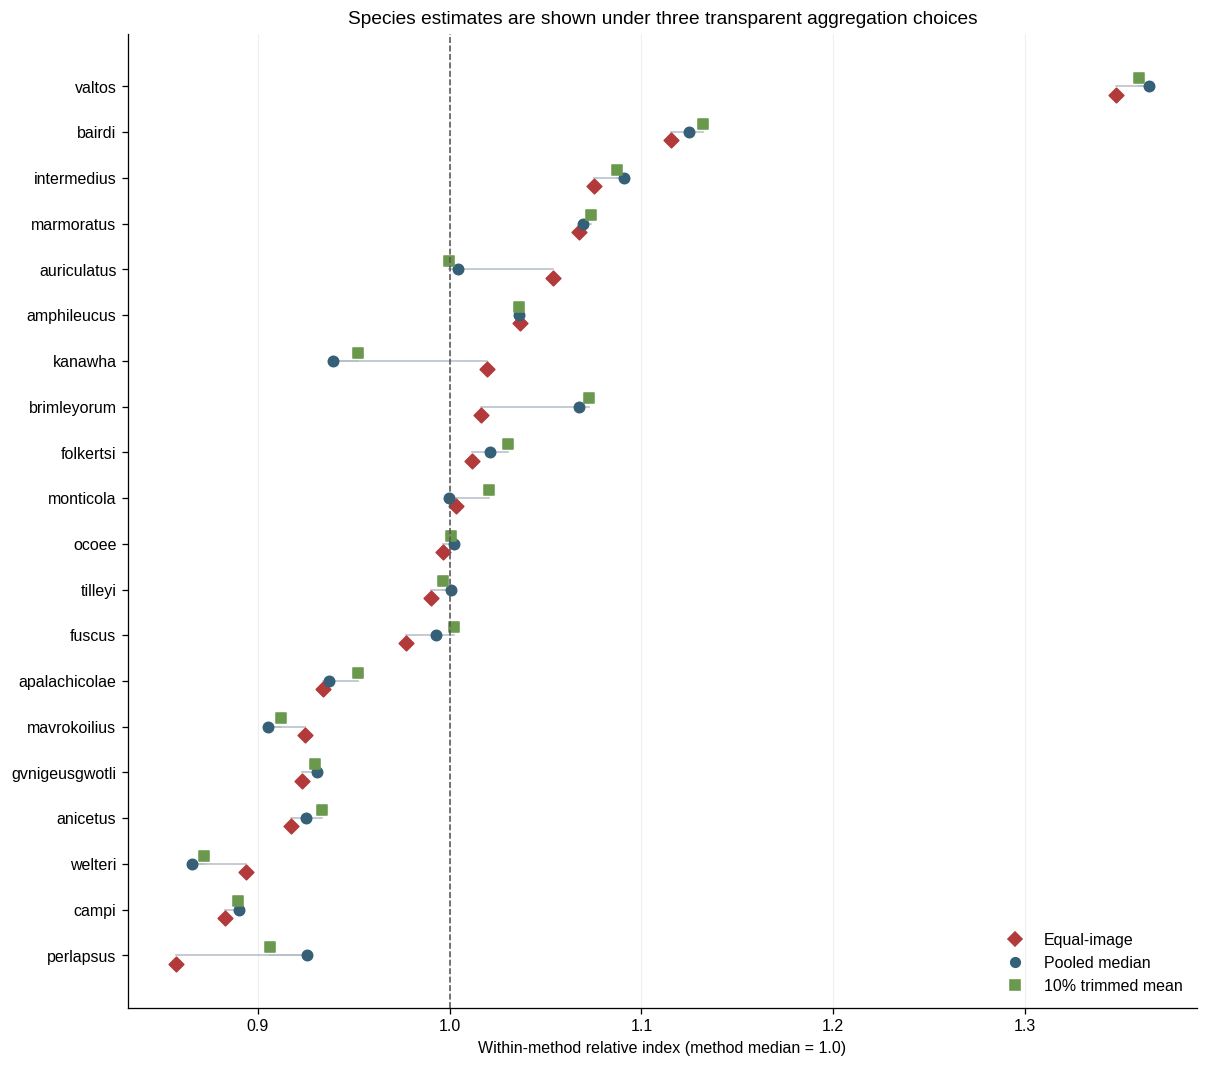

,species,pooled_median_difference_pct,trimmed_mean_difference_pct,max_abs_shift_pct
6,D. kanawha,-8.620750,-7.845138,8.620750
19,D. perlapsus,7.040114,4.296301,7.040114
4,D. auriculatus,-5.511722,-6.423968,6.423968
7,D. brimleyorum,4.150937,4.097254,4.150937
17,D. welteri,-3.969918,-3.789938,3.969918
14,D. mavrokoilius,-2.869340,-2.648066,2.869340
5,D. amphileucus,-0.872148,-1.405629,1.405629
9,D. monticola,-1.218568,0.351896,1.218568
12,D. fuscus,0.784390,1.178603,1.178603
10,D. ocoee,-0.284281,-0.976797,0.976797


In [10]:
sensitivity = species_summary[[
    "species",
    "iod_equal_image_estimate",
    "iod_pooled_nucleus_median",
    "iod_trimmed_mean_10pct",
]].copy()
method_columns = [
    "iod_equal_image_estimate",
    "iod_pooled_nucleus_median",
    "iod_trimmed_mean_10pct",
]
method_labels = ["Equal-image", "Pooled median", "10% trimmed mean"]
for column in method_columns:
    sensitivity[column + "_index"] = (
        sensitivity[column] / sensitivity[column].median()
    )
order = species_summary.sort_values("relative_iod_index")["species"].tolist()
fig, ax = plt.subplots(figsize=(12, 11))
offsets = [-0.18, 0.0, 0.18]
markers = ["D", "o", "s"]
colors = ["#B33A3A", "#365F78", "#6A994E"]
for y, species in enumerate(order):
    row = sensitivity.loc[sensitivity["species"].eq(species)].iloc[0]
    values = [row[column + "_index"] for column in method_columns]
    ax.plot(values, [y] * 3, color="#B8C0C8", linewidth=1, zorder=1)
    for offset, value, marker, color in zip(offsets, values, markers, colors):
        ax.scatter(value, y + offset, marker=marker, s=42, color=color, zorder=2)
ax.axvline(1.0, color="#555555", linestyle="--", linewidth=1)
ax.set_yticks(range(len(order)), [short_species(value) for value in order])
ax.set_xlabel("Within-method relative index (method median = 1.0)")
ax.set_title("Species estimates are shown under three transparent aggregation choices")
handles = [
    plt.Line2D([], [], marker=marker, linestyle="", color=color, label=label)
    for marker, color, label in zip(markers, colors, method_labels)
]
ax.legend(handles=handles, frameon=False, loc="lower right")
ax.grid(axis="x", alpha=0.18)
save_figure(fig, "05_aggregation_sensitivity.png")
plt.show()
display(
    species_summary[[
        "species",
        "pooled_median_difference_pct",
        "trimmed_mean_difference_pct",
    ]]
    .assign(max_abs_shift_pct=lambda x: x[[
        "pooled_median_difference_pct", "trimmed_mean_difference_pct"
    ]].abs().max(axis=1))
    .sort_values("max_abs_shift_pct", ascending=False)
)


## Technical-quality balance and residual IOD associations


,species,template_species,n_nuclei,standardized_mean_difference_match_log_edge_sharpness,ks_distance_match_log_edge_sharpness,standardized_mean_difference_match_log_relative_ring_noise,ks_distance_match_log_relative_ring_noise,max_abs_standardized_mean_difference,max_ks_distance,passes_prespecified_balance_thresholds
0,D. amphileucus,D. apalachicolae,33,0.049932,0.147420,0.007598,0.099099,0.049932,0.147420,True
1,D. anicetus,D. apalachicolae,39,0.004167,0.092862,-0.015578,0.127512,0.015578,0.127512,True
2,D. apalachicolae,D. apalachicolae,37,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,True
3,D. auriculatus,D. apalachicolae,36,-0.043963,0.120120,-0.004040,0.103604,0.043963,0.120120,True
4,D. bairdi,D. apalachicolae,37,-0.004509,0.108108,-0.010801,0.108108,0.010801,0.108108,True
5,D. brimleyorum,D. apalachicolae,35,0.001098,0.104247,-0.005874,0.070270,0.005874,0.104247,True
6,D. campi,D. apalachicolae,36,0.022809,0.123123,-0.007474,0.103604,0.022809,0.123123,True
7,D. folkertsi,D. apalachicolae,37,-0.003637,0.162162,0.004221,0.108108,0.004221,0.162162,True
8,D. fuscus,D. apalachicolae,35,0.009899,0.110425,-0.014766,0.098842,0.014766,0.110425,True
9,D. gvnigeusgwotli,D. apalachicolae,37,0.018011,0.108108,-0.034232,0.162162,0.034232,0.162162,True


,quality_feature,within_species_centered_spearman_rho,p_value_descriptive_only,n_nuclei
0,match_log_edge_sharpness,-0.116424,0.001740,721
1,match_log_relative_ring_noise,-0.007453,0.841661,721


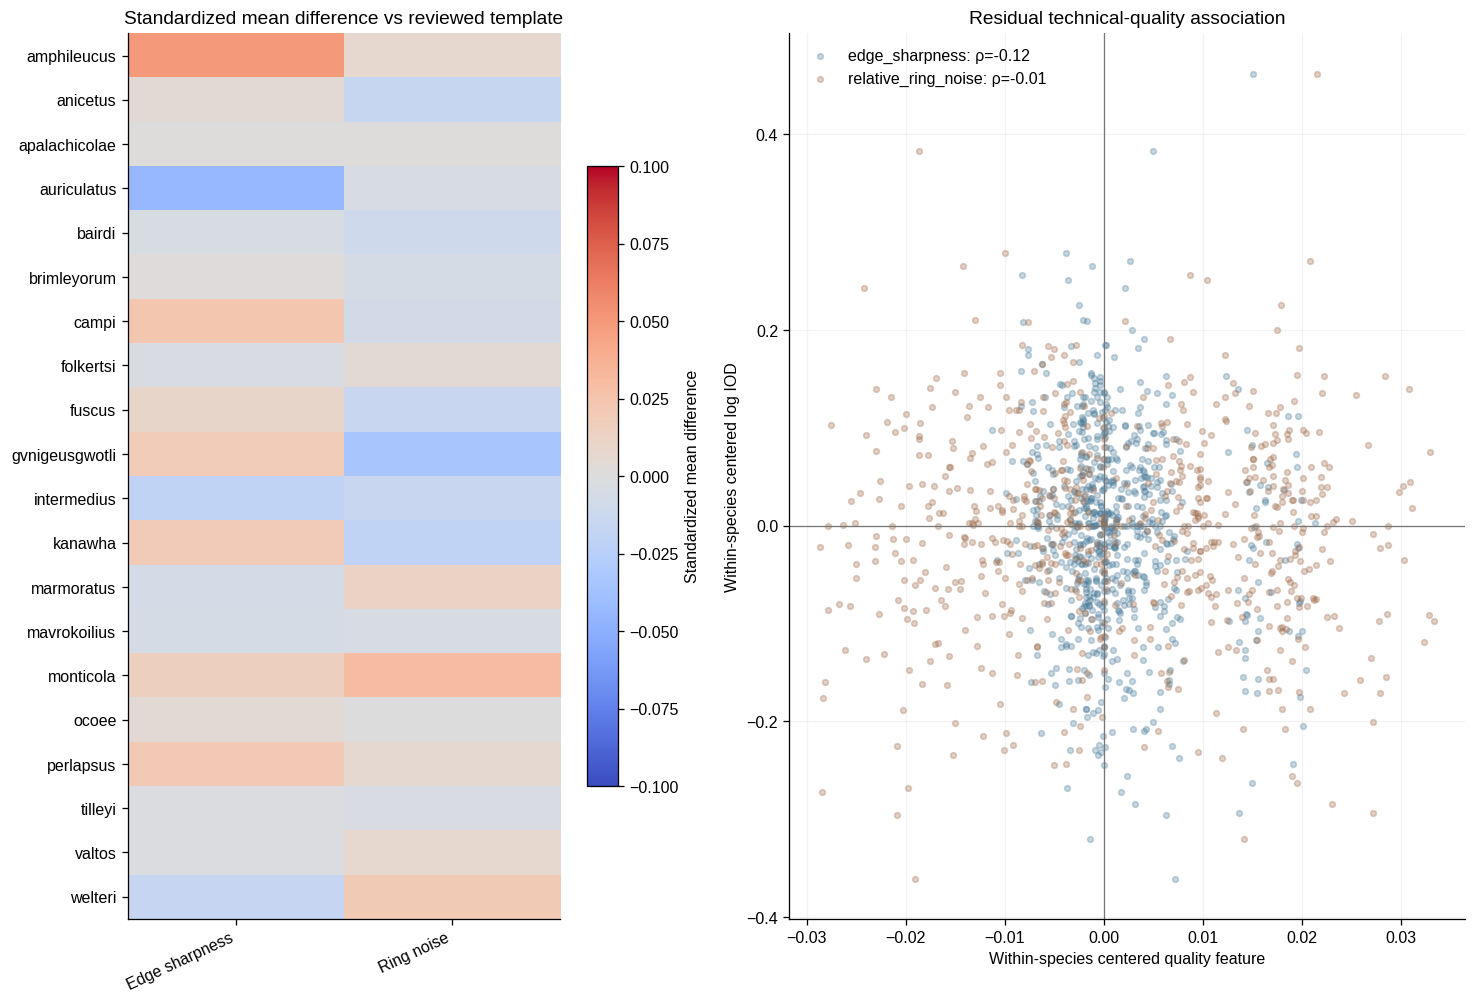

Worst absolute standardized mean difference: 0.05
Worst KS distance: 0.179


In [11]:
display(quality_balance)
display(quality_residual)

balance_plot = quality_balance.sort_values("species")
mean_columns = [
    "standardized_mean_difference_match_log_edge_sharpness",
    "standardized_mean_difference_match_log_relative_ring_noise",
]
matrix = balance_plot[mean_columns].to_numpy()
fig, axes = plt.subplots(1, 2, figsize=(15, 10), gridspec_kw={"width_ratios": [1.0, 1.25]})
image = axes[0].imshow(matrix, cmap="coolwarm", vmin=-0.10, vmax=0.10, aspect="auto")
axes[0].set_yticks(range(len(balance_plot)), [short_species(v) for v in balance_plot["species"]])
axes[0].set_xticks([0, 1], ["Edge sharpness", "Ring noise"], rotation=25, ha="right")
axes[0].set_title("Standardized mean difference vs reviewed template")
fig.colorbar(image, ax=axes[0], shrink=0.7, label="Standardized mean difference")

centered_log_iod = np.log(frozen["nuc_iod"]) - np.log(frozen["nuc_iod"]).groupby(
    frozen["species"]
).transform("median")
feature_colors = ["#477998", "#9C6644"]
for feature, color in zip(analysis.MATCH_FEATURES, feature_colors):
    centered_quality = frozen[feature] - frozen[feature].groupby(
        frozen["species"]
    ).transform("median")
    rho = quality_residual.loc[
        quality_residual["quality_feature"].eq(feature),
        "within_species_centered_spearman_rho",
    ].iloc[0]
    axes[1].scatter(
        centered_quality,
        centered_log_iod,
        s=13,
        alpha=0.30,
        color=color,
        label=f"{feature.replace('match_log_', '')}: ρ={rho:.2f}",
    )
axes[1].axhline(0, color="#777777", linewidth=0.8)
axes[1].axvline(0, color="#777777", linewidth=0.8)
axes[1].set_xlabel("Within-species centered quality feature")
axes[1].set_ylabel("Within-species centered log IOD")
axes[1].set_title("Residual technical-quality association")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.14)
save_figure(fig, "06_quality_diagnostics.png")
plt.show()
print(
    "Worst absolute standardized mean difference:",
    round(quality_balance["max_abs_standardized_mean_difference"].max(), 3),
)
print(
    "Worst KS distance:",
    round(quality_balance["max_ks_distance"].max(), 3),
)


## Direct reading of the current results


In [12]:
top = species_summary.iloc[0]
bottom = species_summary.iloc[-1]
fold = top["iod_equal_image_estimate"] / bottom["iod_equal_image_estimate"]
single_image = species_summary.loc[
    species_summary["n_images"].eq(1), "species"
].tolist()
intervals_crossing_anchor = int((
    species_summary["relative_iod_ci_low"].le(1.0)
    & species_summary["relative_iod_ci_high"].ge(1.0)
).sum())
method_shift = species_summary.assign(
    max_shift=lambda x: x[[
        "pooled_median_difference_pct", "trimmed_mean_difference_pct"
    ]].abs().max(axis=1)
).sort_values("max_shift", ascending=False).iloc[0]
rho_area, p_area = spearmanr(
    species_summary["median_nucleus_area_um2"],
    species_summary["iod_equal_image_estimate"],
)
rho_od, p_od = spearmanr(
    species_summary["median_nucleus_mean_od"],
    species_summary["iod_equal_image_estimate"],
)

display(HTML(f"""
<div style="border-left:5px solid #365F78;background:#f4f7f9;padding:14px 18px">
<p><b>Largest relative IOD:</b> {top['species']} ({top['relative_iod_index']:.3f}× the species-median anchor).</p>
<p><b>Smallest relative IOD:</b> {bottom['species']} ({bottom['relative_iod_index']:.3f}×).</p>
<p><b>Observed range:</b> {fold:.2f}-fold from highest to lowest.</p>
<p><b>Rank resolution:</b> {intervals_crossing_anchor} of {len(species_summary)}
intervals cross the 1.0 anchor, so most exact middle ranks should not be treated as
sharply separated.</p>
<p><b>Aggregation sensitivity:</b> the largest shift from equal-image weighting is
{method_shift['max_shift']:.1f}% for {method_shift['species']}.</p>
<p><b>IOD components:</b> species IOD correlates with median nucleus area
(ρ={rho_area:.2f}) and median mean optical density (ρ={rho_od:.2f}). This is expected
because both are algebraic components of IOD.</p>
<p><b>Single-image limitation:</b> {', '.join(single_image)} have only one observed
image/specimen, so their interval cannot measure between-image variation.</p>
</div>
"""))


## Conclusions and next validation step

            1. The frozen panel supports a stable **relative ranking** of
               nuclear IOD across the 20 image-quality-compatible species.
            2. Equal-image weighting is the primary estimate because it avoids
               letting images with more accepted nuclei dominate.
            3. The raw values, image-specific medians, bootstrap intervals,
               alternative aggregations, and technical-quality diagnostics
               remain visible rather than collapsing the evidence to one
               number per species.
            4. Most middle-ranked species have overlapping intervals. The point
               ranking is descriptive, not evidence that every adjacent pair
               differs biologically.
            5. This analysis cannot convert IOD to absolute genome size. That
               requires an independently measured DNA-content standard
               processed under the same staining and imaging protocol.
            6. *D. ochrophaeus* remains excluded from the primary comparison
               because its technical image-quality distribution had limited
               overlap; it belongs only in a labeled sensitivity analysis.


## Reproducibility and exported files


In [13]:
exports = pd.DataFrame([
    {"artifact": "Frozen 721-nucleus source", "path": str(analysis.FROZEN_PATH)},
    {"artifact": "Species result table", "path": str(analysis.SPECIES_SUMMARY_PATH)},
    {"artifact": "Image result table", "path": str(analysis.IMAGE_SUMMARY_PATH)},
    {"artifact": "Frozen quality balance", "path": str(analysis.QUALITY_BALANCE_PATH)},
    {"artifact": "Residual quality diagnostics", "path": str(analysis.QUALITY_RESIDUAL_PATH)},
    {"artifact": "Measured phylogeny figure", "path": str(analysis.FIGURE_DIR / "07_measured_phylogeny_genome_nucleus_cell.png")},
    {"artifact": "Measured phylogeny source table", "path": str(analysis.REPORT_DIR / "phylogeny_genome_nucleus_cell_summary.csv")},
    {"artifact": "Measured phylogeny correlation table", "path": str(analysis.REPORT_DIR / "phylogeny_genome_nucleus_cell_correlations.csv")},
    {"artifact": "Analysis manifest", "path": str(analysis.ANALYSIS_MANIFEST_PATH)},
    {"artifact": "Executed notebook", "path": str(analysis.EXECUTED_NOTEBOOK_PATH)},
    {"artifact": "Rendered HTML", "path": str(analysis.HTML_PATH)},
])
display(exports)
print("Build source notebook:")
print("  uv run python path_analysis/scripts/build_frozen_genome_iod_notebook.py")
print("Build measured phylogeny figure:")
print(
    "  uv run --with biopython python "
    "path_analysis/scripts/build_frozen_genome_iod_phylogeny_figure.py"
)
print("Execute notebook:")
print(
    "  uv run jupyter nbconvert --to notebook --execute "
    "notebooks/presentation/frozen_genome_iod_analysis/frozen_genome_iod_analysis.ipynb "
    "--output frozen_genome_iod_analysis.executed.ipynb "
    "--output-dir notebooks/presentation/frozen_genome_iod_analysis "
    "--ExecutePreprocessor.timeout=300"
)
print("Render HTML:")
print(
    "  uv run jupyter nbconvert --to html "
    "notebooks/presentation/frozen_genome_iod_analysis/"
    "frozen_genome_iod_analysis.executed.ipynb "
    "--output index.html "
    "--output-dir notebooks/presentation/frozen_genome_iod_analysis"
)


,artifact,path
0,Frozen 721-nucleus source,/home/jake/Projects/Desmognathus_TE/path_analy...
1,Species result table,/home/jake/Projects/Desmognathus_TE/notebooks/...
2,Image result table,/home/jake/Projects/Desmognathus_TE/notebooks/...
3,Frozen quality balance,/home/jake/Projects/Desmognathus_TE/notebooks/...
4,Residual quality diagnostics,/home/jake/Projects/Desmognathus_TE/notebooks/...
5,Measured phylogeny figure,/home/jake/Projects/Desmognathus_TE/notebooks/...
6,Measured phylogeny source table,/home/jake/Projects/Desmognathus_TE/notebooks/...
7,Measured phylogeny correlation table,/home/jake/Projects/Desmognathus_TE/notebooks/...
8,Analysis manifest,/home/jake/Projects/Desmognathus_TE/notebooks/...
9,Executed notebook,/home/jake/Projects/Desmognathus_TE/notebooks/...


Build source notebook:
  uv run python path_analysis/scripts/build_frozen_genome_iod_notebook.py
Build measured phylogeny figure:
  uv run --with biopython python path_analysis/scripts/build_frozen_genome_iod_phylogeny_figure.py
Execute notebook:
  uv run jupyter nbconvert --to notebook --execute notebooks/presentation/frozen_genome_iod_analysis/frozen_genome_iod_analysis.ipynb --output frozen_genome_iod_analysis.executed.ipynb --output-dir notebooks/presentation/frozen_genome_iod_analysis --ExecutePreprocessor.timeout=300
Render HTML:
  uv run jupyter nbconvert --to html notebooks/presentation/frozen_genome_iod_analysis/frozen_genome_iod_analysis.executed.ipynb --output index.html --output-dir notebooks/presentation/frozen_genome_iod_analysis
